In [1]:
import pandas as pd 
import sqlite3

In [2]:
conn = sqlite3.connect('../data/checking-logs.sqlite')

In [3]:
commits_per_day = pd.read_sql("""SELECT uid, timestamp
                              FROM checker
                              WHERE uid LIKE "user_%"
                              """, conn)

In [4]:
commits_per_day['timestamp'] = pd.to_datetime(commits_per_day['timestamp'])
commits_per_day['hour'] = commits_per_day['timestamp'].dt.hour
commits_per_day['date'] = commits_per_day['timestamp'].dt.date

In [5]:
bins = [0, 4, 10, 17, 24]
labels = ['night', 'morning', 'afternoon', 'evening']

commits_per_day['daytime'] = pd.cut(commits_per_day['hour'], bins = bins, labels = labels)


In [6]:
commits_by_daytime = (
    commits_per_day
    .groupby(['date', 'daytime'])
    .size()                    # считает строки
    .reset_index(name='commits')  # задаёт имя столбцу с количеством
)
commits_by_daytime.head(12)

C:\Users\Анастасия\AppData\Local\Temp\ipykernel_3404\650469868.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(['date', 'daytime'])


,date,daytime,commits
0,2020-04-17,night,0
1,2020-04-17,morning,13
2,2020-04-17,afternoon,10
3,2020-04-17,evening,0
4,2020-04-18,night,0
5,2020-04-18,morning,1
6,2020-04-18,afternoon,40
7,2020-04-18,evening,28
8,2020-04-19,night,0
9,2020-04-19,morning,11


In [7]:
pivoted = commits_by_daytime.pivot(index='date', columns='daytime', values='commits').fillna(0)
pivoted.head()

daytime,night,morning,afternoon,evening
date,,,,
2020-04-17,0,13,10,0
2020-04-18,0,1,40,28
2020-04-19,0,11,9,11
2020-04-20,0,0,15,10
2020-04-21,0,0,9,16


In [8]:
pivoted.info()

<class 'pandas.core.frame.DataFrame'>
Index: 35 entries, 2020-04-17 to 2020-05-21
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   night      35 non-null     int64
 1   morning    35 non-null     int64
 2   afternoon  35 non-null     int64
 3   evening    35 non-null     int64
dtypes: int64(4)
memory usage: 1.4+ KB


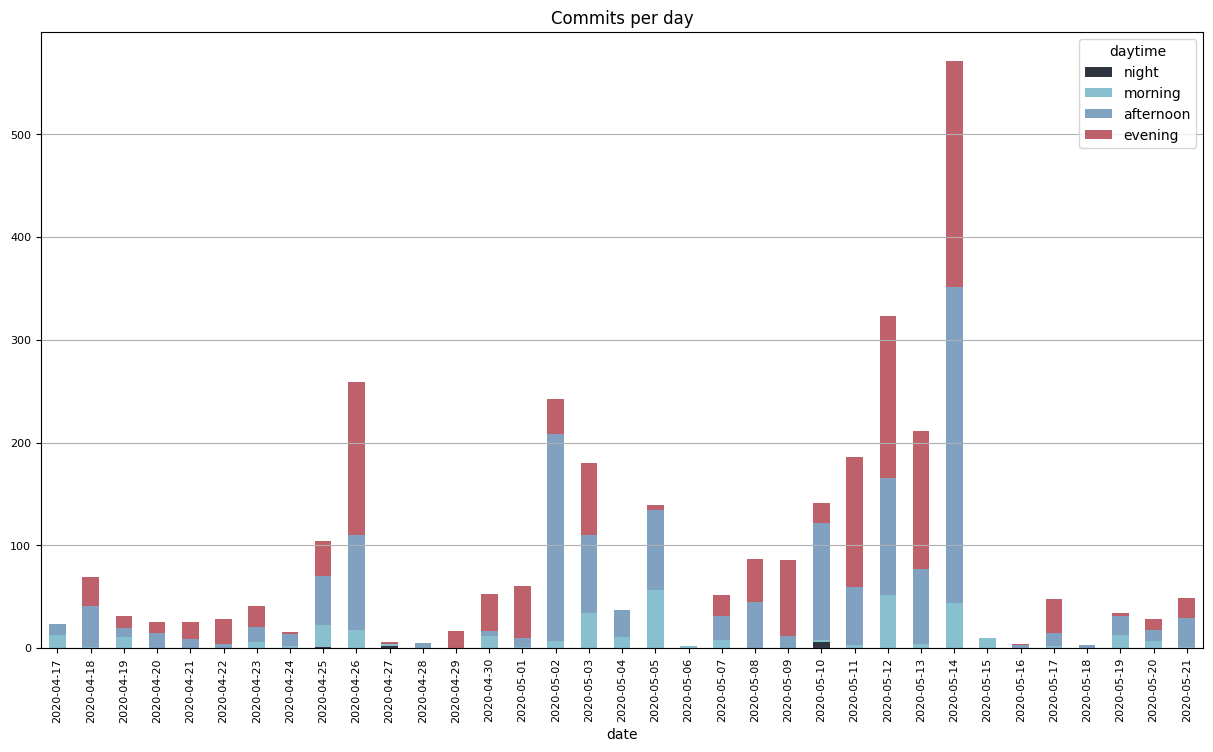

In [9]:
colors = ['#2E3440', '#88C0D0', '#81A1C1', '#BF616A'] 

ax = pivoted.plot(
    kind='bar',
    stacked=True,
    figsize=(15,8),
    fontsize=8,
    color=colors,
    title = 'Commits per day'
)

ax.yaxis.grid(True)

«Когда наши пользователи обычно выполняют лабораторные работы: ночью, утром, днем ​​или вечером?» — ответ заключается в двух наиболее распространенных периодах.

- днем и вечером

В какой день:
наибольшее количество коммитов - 14.05.2022
и при этом количество коммитов вечером больше, чем днем - 12.05.2022

In [10]:
conn.close()